# House Price Prediction

## 1. Problem Statement
With 79 explanatory variables describing (almost) every aspect of residential homes in Ames, Iowa, this competition challenges you to predict the final price of each home.

## 2. Data Description

- SalePrice - the property's sale price in dollars. This is the target variable that you're trying to predict.
- MSSubClass: The building class
- MSZoning: The general zoning classification
- LotFrontage: Linear feet of street connected to property
- LotArea: Lot size in square feet
- Street: Type of road access
- Alley: Type of alley access
- LotShape: General shape of property
- LandContour: Flatness of the property
- Utilities: Type of utilities available
- LotConfig: Lot configuration
- LandSlope: Slope of property
- Neighborhood: Physical locations within Ames city limits
- Condition1: Proximity to main road or railroad
- Condition2: Proximity to main road or railroad (if a second is present)
- BldgType: Type of dwelling
- HouseStyle: Style of dwelling
- OverallQual: Overall material and finish quality
- OverallCond: Overall condition rating
- YearBuilt: Original construction date
- YearRemodAdd: Remodel date
- RoofStyle: Type of roof
- RoofMatl: Roof material
- Exterior1st: Exterior covering on house
- Exterior2nd: Exterior covering on house (if more than one material)
- MasVnrType: Masonry veneer type
- MasVnrArea: Masonry veneer area in square feet
- ExterQual: Exterior material quality
- ExterCond: Present condition of the material on the exterior
- Foundation: Type of foundation
- BsmtQual: Height of the basement
- BsmtCond: General condition of the basement
- BsmtExposure: Walkout or garden level basement walls
- BsmtFinType1: Quality of basement finished area
- BsmtFinSF1: Type 1 finished square feet
- BsmtFinType2: Quality of second finished area (if present)
- BsmtFinSF2: Type 2 finished square feet
- BsmtUnfSF: Unfinished square feet of basement area
- TotalBsmtSF: Total square feet of basement area
- Heating: Type of heating
- HeatingQC: Heating quality and condition
- CentralAir: Central air conditioning
- Electrical: Electrical system
- 1stFlrSF: First Floor square feet
- 2ndFlrSF: Second floor square feet
- LowQualFinSF: Low quality finished square feet (all floors)
- GrLivArea: Above grade (ground) living area square feet
- BsmtFullBath: Basement full bathrooms
- BsmtHalfBath: Basement half bathrooms
- FullBath: Full bathrooms above grade
- HalfBath: Half baths above grade
- Bedroom: Number of bedrooms above basement level
- Kitchen: Number of kitchens
- KitchenQual: Kitchen quality
- TotRmsAbvGrd: Total rooms above grade (does not include bathrooms)
- Functional: Home functionality rating
- Fireplaces: Number of fireplaces
- FireplaceQu: Fireplace quality
- GarageType: Garage location
- GarageYrBlt: Year garage was built
- GarageFinish: Interior finish of the garage
- GarageCars: Size of garage in car capacity
- GarageArea: Size of garage in square feet
- GarageQual: Garage quality
- GarageCond: Garage condition
- PavedDrive: Paved driveway
- WoodDeckSF: Wood deck area in square feet
- OpenPorchSF: Open porch area in square feet
- EnclosedPorch: Enclosed porch area in square feet
- 3SsnPorch: Three season porch area in square feet
- ScreenPorch: Screen porch area in square feet
- PoolArea: Pool area in square feet
- PoolQC: Pool quality
- Fence: Fence quality
- MiscFeature: Miscellaneous feature not covered in other categories
- MiscVal: $Value of miscellaneous feature
- MoSold: Month Sold
- YrSold: Year Sold
- SaleType: Type of sale
- SaleCondition: Condition of sale

## 3. Data EDA

### 3.1 Data Structure and Quality

#### 3.1.1 Shape and Types

In [114]:
import pandas as pd

# importing the dataset
house_pricing = pd.read_csv("train.csv")

In [115]:
# checking the shape of the data
house_pricing.shape

(1460, 81)

In [116]:
house_pricing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

##### 3.1.1.1 Separating features into Numeric, Categorical, Ordinal

In [117]:
numeric_features = house_pricing.select_dtypes(include=["int64","float64"]).columns.tolist()
numeric_features

['Id',
 'MSSubClass',
 'LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold',
 'SalePrice']

In [118]:
# checking suspicious numeric columns
for col in numeric_features:
    if house_pricing[col].nunique() < 15:
        print(col, house_pricing[col].unique())

OverallQual [ 7  6  8  5  9  4 10  3  1  2]
OverallCond [5 8 6 7 4 2 3 9 1]
BsmtFullBath [1 0 2 3]
BsmtHalfBath [0 1 2]
FullBath [2 1 3 0]
HalfBath [1 0 2]
BedroomAbvGr [3 4 1 2 0 5 6 8]
KitchenAbvGr [1 2 3 0]
TotRmsAbvGrd [ 8  6  7  9  5 11  4 10 12  3  2 14]
Fireplaces [0 1 2 3]
GarageCars [2 3 1 0 4]
PoolArea [  0 512 648 576 555 480 519 738]
MoSold [ 2  5  9 12 10  8 11  4  1  7  3  6]
YrSold [2008 2007 2006 2009 2010]


`OverallQual`, `OverallCond` are ordinal features

There's also `MSSubClass` which consists of codes for the type of dwelling, the codes have no numerical/ordinal significance
Thus,

`MSSubClass` is categorical feature

In [119]:
# checking binary features
object_cols = house_pricing.select_dtypes(include=["object"]).columns.tolist()

categorical_binary_features = []
doubtful_features = []

for col in object_cols:
    n_unique = house_pricing[col].nunique(dropna=True)

    if n_unique == 2:
        categorical_binary_features.append(col)
    else:
        doubtful_features.append(col)

categorical_binary_features

['Street', 'Alley', 'Utilities', 'CentralAir']

In [120]:
for col in categorical_binary_features:
    print(house_pricing[col].value_counts())
    print("----------")

Street
Pave    1454
Grvl       6
Name: count, dtype: int64
----------
Alley
Grvl    50
Pave    41
Name: count, dtype: int64
----------
Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64
----------
CentralAir
Y    1365
N      95
Name: count, dtype: int64
----------


In [121]:
house_pricing.groupby("Street")["SalePrice"].mean()

Street
Grvl    130190.500000
Pave    181130.538514
Name: SalePrice, dtype: float64

In [122]:
house_pricing.groupby("Utilities")["SalePrice"].mean()

Utilities
AllPub    180950.95682
NoSeWa    137500.00000
Name: SalePrice, dtype: float64

Even though `Street`, `Utilities` have a very high class bias, they seem to have some effect on the target, so they are not beinig dropped

In [123]:
doubtful_features

['MSZoning',
 'LotShape',
 'LandContour',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Heating',
 'HeatingQC',
 'Electrical',
 'KitchenQual',
 'Functional',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'PoolQC',
 'Fence',
 'MiscFeature',
 'SaleType',
 'SaleCondition']

Finally, after analysis
- `OverallQual`
- `OverallCond`
- `ExterQual`
- `ExterCond`
- `BsmtQual`
- `BsmtCond`
- `BsmtExposure`
- `BsmtFinType1`
- `BsmtFinType2`
- `HeatingQC`
- `KitchenQual`
- `FireplaceQu`
- `GarageQual`
- `GarageCond`
- `PoolQC`
- `LandSlope`
- `LotShape`
- `Functional`

are found to be ordinal

In [124]:
# setting up ordinal scales
quality_scale = {
    'None': 0,
    'Po': 1,
    'Fa': 2,
    'TA': 3,
    'Gd': 4,
    'Ex': 5
}

bsmt_finish_scale = {
    'None': 0,
    'Unf': 1,
    'LwQ': 2,
    'Rec': 3,
    'BLQ': 4,
    'ALQ': 5,
    'GLQ': 6
}

land_slope_scale = {
    'Sev': 1,
    'Mod': 2,
    'Gtl': 3
}

lot_shape_scale = {
    'IR3': 1,
    'IR2': 2,
    'IR1': 3,
    'Reg': 4
}

functional_scale = {
    'Sal': 1,
    'Sev': 2,
    'Maj2': 3,
    'Maj1': 4,
    'Mod': 5,
    'Min2': 6,
    'Min1': 7,
    'Typ': 8
}

bsmt_exp_scale = {
    'None': 0,
    'No': 1,
    'Mn': 2,
    'Av': 3,
    'Gd': 4
}

In [125]:
# ordinal mapping
ordinal_mappings = {
    'ExterQual': quality_scale,
    'ExterCond': quality_scale,
    'BsmtQual': quality_scale,
    'BsmtCond': quality_scale,
    'BsmtExposure': bsmt_exp_scale,
    'HeatingQC': quality_scale,
    'KitchenQual': quality_scale,
    'FireplaceQu': quality_scale,
    'GarageQual': quality_scale,
    'GarageCond': quality_scale,
    'PoolQC': quality_scale,
    'BsmtFinType1': bsmt_finish_scale,
    'BsmtFinType2': bsmt_finish_scale,
    'LandSlope': land_slope_scale,
    'LotShape': lot_shape_scale,
    'Functional': functional_scale,
    'OverallQual': None,
    'OverallCond': None,
}

In [126]:
ordinal_features = list(ordinal_mappings.keys())

categorical_features = [
    col for col in object_cols
    if col not in ordinal_features
]
categorical_features.append("MSSubClass")

numeric_features = [
    col for col in house_pricing.columns
    if col not in categorical_features
    and col not in ordinal_features
    and col != "SalePrice"
]

In [127]:
# checking if some cols got left or were duplicated
print(len(numeric_features))
print(len(ordinal_features))
print(len(categorical_features))

34
18
28


Sum = 80, which checks out as the target was removed

In [128]:
FEATURE_TYPES = {
    "ordinal": ordinal_features,
    "nominal": categorical_features,
    "numeric": numeric_features
}

#### 3.1.2 Missing Values

In [129]:
# assessing the missing values
missing = pd.DataFrame({
    "Missing_Count": house_pricing.isna().sum(),
    "Missing_Percentage": house_pricing.isna().mean() * 100
})

missing = missing[missing["Missing_Count"] > 0]
missing.sort_values("Missing_Count", ascending=False)

,Missing_Count,Missing_Percentage
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


Apart from `LotFrontage`, `Electrical` all are structural absence

### 3.2 Univariate Analysis

#### 3.2.1 Analysing the target variable

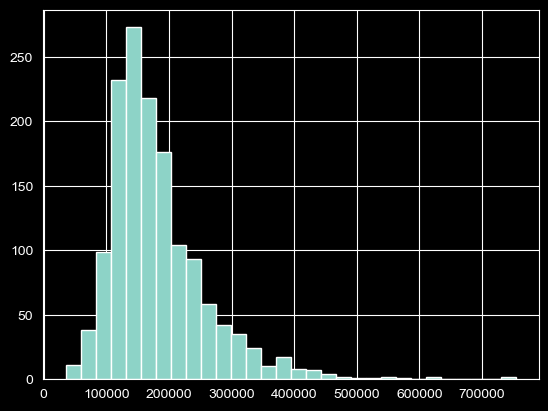

In [130]:
import matplotlib.pyplot as plt

plt.hist(house_pricing["SalePrice"], bins=30);

In [131]:
house_pricing['SalePrice'].skew()

np.float64(1.8828757597682129)

`SalePrice` is left skewed. It should be beneficial to apply log transform to introduce normality, even though were using tree based models.

After we know the feature importance we can selective check the skewness of the important features. If it's large (>2) we can transform them, for (potentially) better results.

#### 3.2.2 Analysing categorical features

In [132]:
with open('categorical_univariate_analysis.txt', 'w') as file:
    for features in FEATURE_TYPES["nominal"]:
        file.write(house_pricing.groupby(features)["SalePrice"].mean().sort_values().to_string())
        file.write("\n-------------------\n")

After analysing the text file, it's safe to say there's no low-signal categorical features, as the $max(mean) - min(mean)$ for every category is significant.

#### 3.2.3 Analysing the ordinal features

In [133]:
with open('ordinal_univariate_analysis.txt', 'w') as file:
    for features in FEATURE_TYPES["ordinal"]:
        file.write(house_pricing.groupby(features)["SalePrice"].mean().to_string())
        file.write("\n-------------------\n")

Among ordinal features there's an anomaly with `GarageCond`, where $Gd-mean > Ex-mean$. But this could be due to sample size imbalance, as Ex garages might be rare.

There's also a non-monotonic pattern with `OverallCond` where the max mean is at 5. This can also be because most houses in the sample cluster around 5.

In [134]:
# checking the analysis
house_pricing.value_counts(["GarageCond"]), house_pricing.value_counts(["OverallCond"])

(GarageCond
 TA            1326
 Fa              35
 Gd               9
 Po               7
 Ex               2
 Name: count, dtype: int64,
 OverallCond
 5              821
 6              252
 7              205
 8               72
 4               57
 3               25
 9               22
 2                5
 1                1
 Name: count, dtype: int64)

This proves the analysis

### 3.3 Multivariate Analysis

In [141]:
# correlation matrix
import numpy as np
corr = house_pricing[numeric_features].corr()

# keep only upper triangle to avoid duplicates and self correlation
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# Get pairs with correlation > 0.7
high_corr_pairs = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if abs(upper.loc[row, col]) > 0.7
]

high_corr_pairs

[('1stFlrSF', 'TotalBsmtSF', np.float64(0.8195299750050339)),
 ('TotRmsAbvGrd', 'GrLivArea', np.float64(0.8254893743088425)),
 ('GarageYrBlt', 'YearBuilt', np.float64(0.8256674841743408)),
 ('GarageArea', 'GarageCars', np.float64(0.882475414281462))]

These can be analysed to generate improved features, like:

``` python
FootprintSize = max(1stFlrSF, TotalBsmtSF)
AvgRoomSize = GrLivArea / TotRmsAbvGrd

GarageAge = YrSold - GarageYrBlt
HouseAge = YrSold - YearBuilt
GarageBuiltLater = GarageYrBlt > YearBuilt

AreaPerCar = GarageArea / (GarageCars + 1)
```

### 3.4 Checking for outliers

In [142]:
house_pricing.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

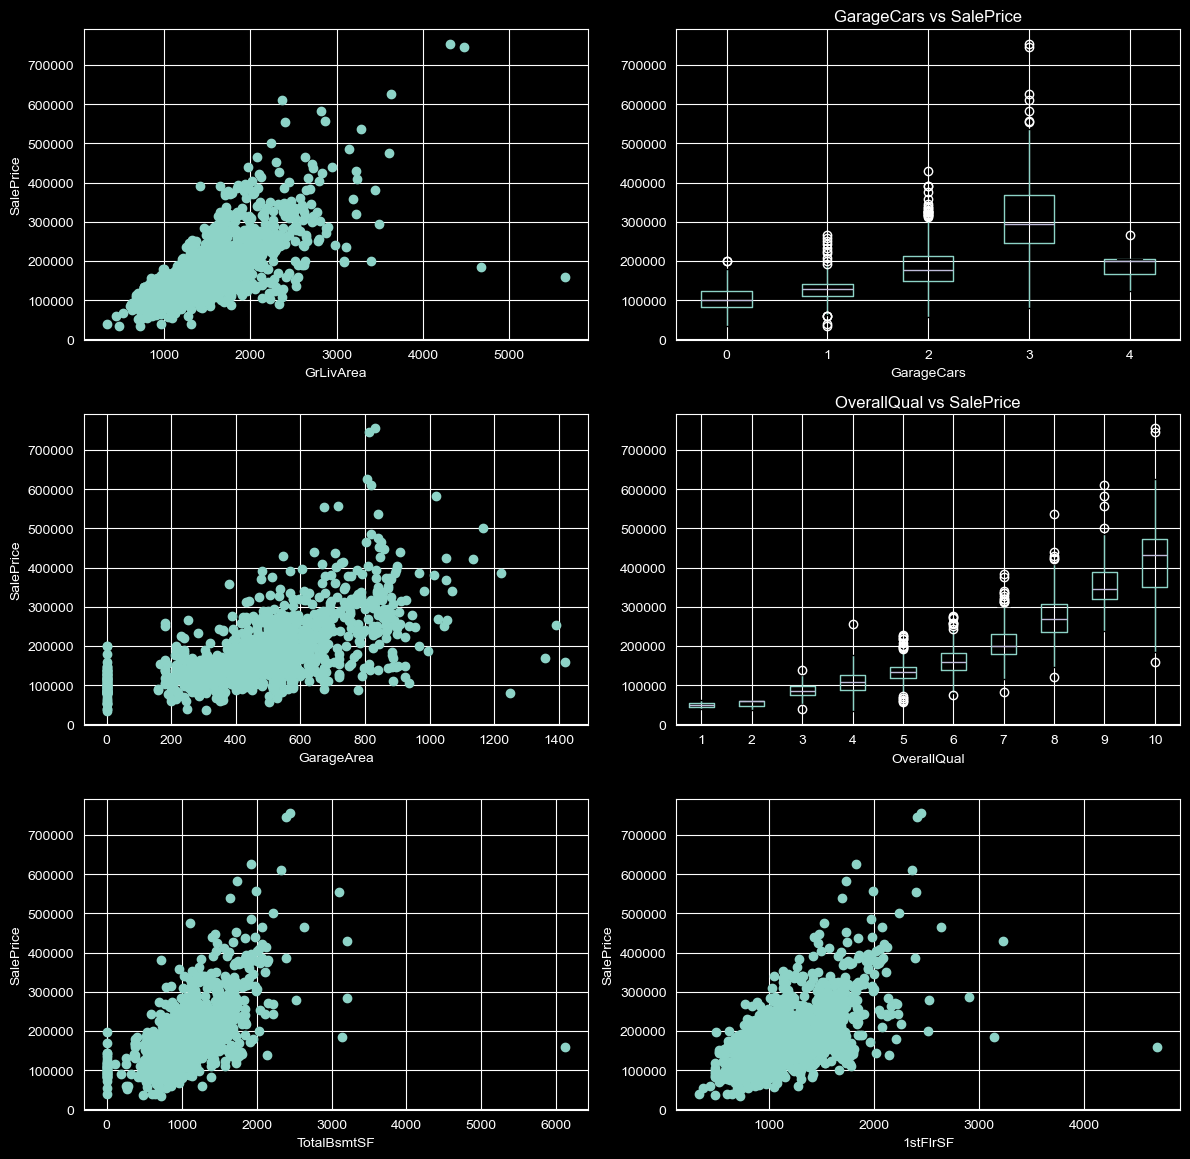

In [144]:
fig, ax = plt.subplots(3, 2, figsize=(12, 12))

# scatter plot for numeric features
ax[0, 0].scatter(house_pricing["GrLivArea"], house_pricing["SalePrice"])
ax[0, 0].set_xlabel("GrLivArea")
ax[0, 0].set_ylabel("SalePrice")

ax[1, 0].scatter(house_pricing["GarageArea"], house_pricing["SalePrice"])
ax[1, 0].set_xlabel("GarageArea")
ax[1, 0].set_ylabel("SalePrice")

ax[2, 0].scatter(house_pricing["TotalBsmtSF"], house_pricing["SalePrice"])
ax[2, 0].set_xlabel("TotalBsmtSF")
ax[2, 0].set_ylabel("SalePrice")

ax[2, 1].scatter(house_pricing["1stFlrSF"], house_pricing["SalePrice"])
ax[2, 1].set_xlabel("1stFlrSF")
ax[2, 1].set_ylabel("SalePrice")


# boxplot for categorical features
house_pricing.boxplot(
    column="SalePrice",
    by="GarageCars",
    ax=ax[0, 1]
)
ax[0, 1].set_title("GarageCars vs SalePrice")
ax[0, 1].set_xlabel("GarageCars")

house_pricing.boxplot(
    column="SalePrice",
    by="OverallQual",
    ax=ax[1, 1]
)
ax[1, 1].set_title("OverallQual vs SalePrice")
ax[1, 1].set_xlabel("OverallQual")

plt.tight_layout()
plt.suptitle("")
plt.show()

AAfter checking th ebaseline we can remove these outliers to check for improvements

``` python
house_pricing = house_pricing[~((house_pricing['GrLivArea'] > 4000) & (house_pricing['SalePrice'] < 200000))]
house_pricing = house_pricing[~((house_pricing['GarageArea'] > 1200) & (house_pricing['SalePrice'] < 200000))]
house_pricing = house_pricing[~((house_pricing['TotalBsmtSF'] > 6000) & (house_pricing['SalePrice'] < 200000))]
house_pricing = house_pricing[~((house_pricing['1stFlrSF'] > 4000) & (house_pricing['SalePrice'] < 200000))]
```

### 3.5 Feature engineering

In [145]:
# FootprintSize = max(1stFlrSF, TotalBsmtSF)
house_pricing["FootprintSize"] = np.maximum(house_pricing["1stFlrSF"], house_pricing["TotalBsmtSF"])

# AvgRoomSize = GrLivArea / TotRmsAbvGrd
house_pricing["AvgRoomSize"] = (house_pricing["GrLivArea"] / house_pricing["TotRmsAbvGrd"])

# GarageAge = YrSold - GarageYrBlt
house_pricing["GarageAge"] = (house_pricing["YrSold"] - house_pricing["GarageYrBlt"])

# HouseAge = YrSold - YearBuilt
house_pricing["HouseAge"] = (house_pricing["YrSold"] - house_pricing["YearBuilt"])

# GarageBuiltLater = GarageYrBlt > YearBuilt
house_pricing["GarageBuiltLater"] = (house_pricing["GarageYrBlt"] > house_pricing["YearBuilt"]).astype(int)

# AreaPerCar = GarageArea / (GarageCars + 1)
house_pricing["AreaPerCar"] = (house_pricing["GarageArea"] / (house_pricing["GarageCars"] + 1))

### 3.6 Normalizing the target

In [146]:
# log transforming the target
house_pricing["SalePrice"] = np.log1p(house_pricing["SalePrice"])

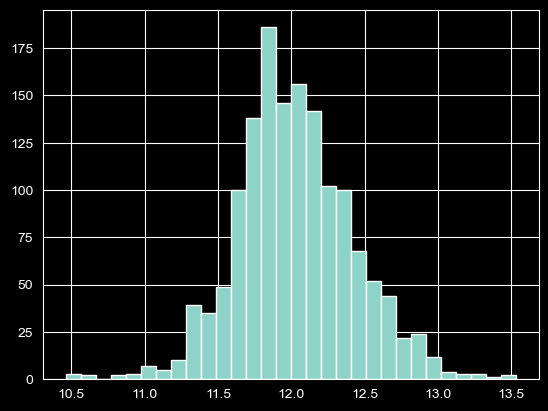

In [147]:
plt.hist(house_pricing["SalePrice"], bins=30);